In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


In [2]:
columns = [
'duration','protocol_type','service','flag','src_bytes','dst_bytes',
'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
'num_shells','num_access_files','num_outbound_cmds','is_host_login',
'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
'dst_host_same_srv_rate','dst_host_diff_srv_rate',
'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
'dst_host_serror_rate','dst_host_srv_serror_rate',
'dst_host_rerror_rate','dst_host_srv_rerror_rate',
'label','difficulty'
]


In [3]:
train = pd.read_csv("KDDTrain+.txt", names=columns)
test = pd.read_csv("KDDTest+.txt", names=columns)

train.head()



,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [4]:
train['label'] = train['label'].apply(lambda x: 0 if x == 'normal' else 1)
test['label'] = test['label'].apply(lambda x: 0 if x == 'normal' else 1)


In [5]:
features = [
    'duration',
    'src_bytes',
    'dst_bytes',
    'wrong_fragment',
    'urgent',
    'num_failed_logins',
    'count',
    'srv_count',
    'serror_rate'
]

X_train = train[features]
y_train = train['label']

X_test = test[features]
y_test = test['label']


In [6]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [7]:
preds = model.predict(X_test)
accuracy_score(y_test, preds)


0.7657469836763662

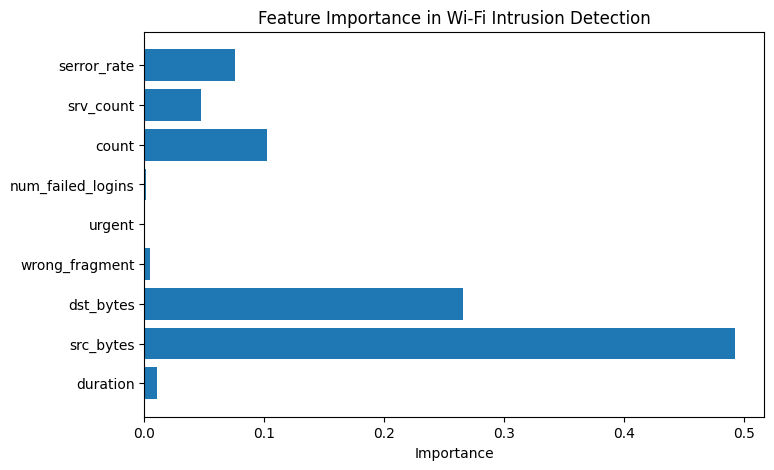

In [8]:
importances = model.feature_importances_

plt.figure(figsize=(8,5))
plt.barh(features, importances)
plt.title("Feature Importance in Wi-Fi Intrusion Detection")
plt.xlabel("Importance")
plt.show()


In [9]:
sample = pd.DataFrame([{
    'duration': 1,
    'src_bytes': 15000,
    'dst_bytes': 300,
    'wrong_fragment': 0,
    'urgent': 0,
    'num_failed_logins': 4,
    'count': 40,
    'srv_count': 20,
    'serror_rate': 0.9
}])

print("🚨 ATTACK" if model.predict(sample)[0] else "✅ NORMAL")


✅ NORMAL


In [10]:
import joblib
joblib.dump(model, "wifi_firewall_model.pkl")


['wifi_firewall_model.pkl']

In [11]:
model = joblib.load("wifi_firewall_model.pkl")



In [12]:
!pip install scapy




[notice] A new release of pip is available: 23.1.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
import time
import threading
import numpy as np

from scapy.all import sniff, IP

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation



In [14]:
# These MUST already exist from your previous work
# model = trained RandomForestClassifier
# features = list of selected NSL-KDD features

print("Model loaded:", model)
print("Features used:", features)


Model loaded: RandomForestClassifier(n_jobs=-1, random_state=42)
Features used: ['duration', 'src_bytes', 'dst_bytes', 'wrong_fragment', 'urgent', 'num_failed_logins', 'count', 'srv_count', 'serror_rate']


In [15]:
class AegisSentinel:
    def __init__(self, model, feature_names):
        self.model = model
        self.features = feature_names
        self.threat = {
            "confidence": 0,
            "rate": 0
        }

    def map_packet_to_features(self, pkt):
        """
        Convert live packet → NSL-KDD-style feature vector
        (SIMULATED mapping for demo safety)
        """
        size = len(pkt)

        duration = 1
        src_bytes = size
        dst_bytes = int(size * 0.6)

        feature_vector = [
            duration,        # duration
            src_bytes,       # src_bytes
            dst_bytes,       # dst_bytes
            0,               # wrong_fragment
            0,               # urgent
            0,               # num_failed_logins
            10,              # count
            5,               # srv_count
            0.2              # serror_rate
        ]

        return np.array([feature_vector])

    def analyze_packet(self, pkt):
        if not pkt.haslayer(IP):
            return

        X_live = self.map_packet_to_features(pkt)
        confidence = self.model.predict_proba(X_live)[0][1]

        self.threat["confidence"] = confidence
        self.threat["rate"] = len(pkt)

        if confidence > 0.85:
            print(f"🔥 ALERT | High-risk traffic | confidence={confidence:.2f}")
        elif confidence > 0.45:
            print(f"⚠️ Suspicious traffic | confidence={confidence:.2f}")



In [16]:
def start_sniffing(aegis):
    print("📡 Live packet capture started...")
    sniff(prn=aegis.analyze_packet, store=0)


In [17]:
def launch_dashboard(aegis):
    plt.style.use("dark_background")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7))

    confidence_history = [0] * 60
    rate_history = [0] * 60

    def animate(i):
        confidence_history.append(aegis.threat["confidence"])
        rate_history.append(aegis.threat["rate"])

        ax1.clear()
        ax1.plot(rate_history[-60:], linewidth=2)
        ax1.set_title("Packet Throughput")

        ax2.clear()
        ax2.fill_between(range(60), confidence_history[-60:], alpha=0.4)
        ax2.axhline(0.85, linestyle="--", label="Alert Threshold")
        ax2.set_ylim(0, 1)
        ax2.set_title("AI Threat Confidence")
        ax2.legend()

    FuncAnimation(fig, animate, interval=500)
    plt.tight_layout()
    plt.show()



In [18]:
aegis = AegisSentinel(model, features)
print("✅ AEGIS Sentinel initialized")



✅ AEGIS Sentinel initialized


C:\Users\aggni\AppData\Local\Temp\ipykernel_7864\1608378600.py:23: UserWarning: frames=None which we can infer the length of, did not pass an explicit *save_count* and passed cache_frame_data=True.  To avoid a possibly unbounded cache, frame data caching has been disabled. To suppress this warning either pass `cache_frame_data=False` or `save_count=MAX_FRAMES`.
  FuncAnimation(fig, animate, interval=500)


📡 Live packet capture started...


c:\Users\aggni\AppData\Local\Programs\Python\Python311\Lib\site-packages\matplotlib\animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


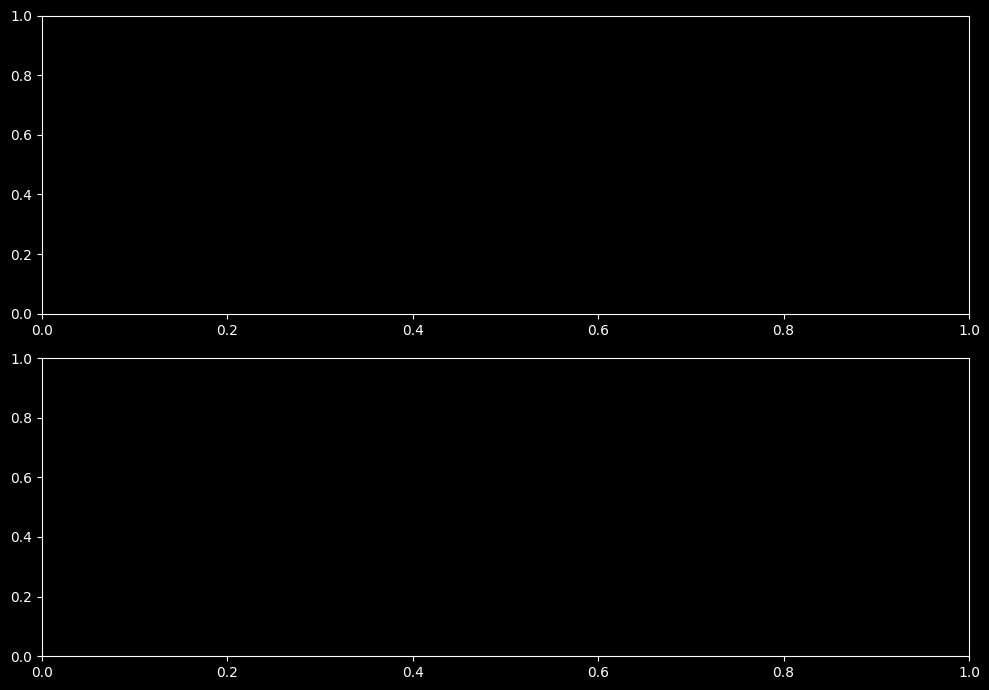

In [19]:
threading.Thread(
    target=start_sniffing,
    args=(aegis,),
    daemon=True
).start()

launch_dashboard(aegis)



In [20]:
from scapy.all import sniff

def test_packet(pkt):
    print("Packet captured")

sniff(prn=test_packet, count=5)


Packet captured
Packet captured
Packet captured


c:\Users\aggni\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Packet captured
Packet captured


<Sniffed: TCP:5 UDP:0 ICMP:0 Other:0>

In [ ]:
import joblib

joblib.dump(model, "aegis_rf_model.pkl")
joblib.dump(features, "aegis_features.pkl")

print("Model and features saved")


c:\Users\aggni\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Model and features saved


c:\Users\aggni\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\aggni\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\aggni\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\aggni\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\aggni\AppData\Local\Programs\Python\Python311\Lib\site-packages\skl